In [2]:
import numpy as np
import random
import os
from skimage.io import imread 
import matplotlib.pyplot as plt
from BatchGeneratorTripletLoss import BatchGenerator
from tensorflow import keras
from keras import layers, models, metrics, optimizers
from keras.applications import densenet, DenseNet121
from keras import ops
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pickle
from scipy.spatial import distance

In [3]:
INPUT = (112, 112, 3)

In [4]:
base_cnn = DenseNet121(
    weights="imagenet", input_shape=INPUT, include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = models.Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

In [5]:
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = ops.sum(tf.square(anchor - positive), -1)
        an_distance = ops.sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=INPUT)
positive_input = layers.Input(name="positive", shape=INPUT)
negative_input = layers.Input(name="negative", shape=INPUT)

distances = DistanceLayer()(
    embedding(densenet.preprocess_input(anchor_input)),
    embedding(densenet.preprocess_input(positive_input)),
    embedding(densenet.preprocess_input(negative_input)),
)

siamese_network = models.Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

In [6]:
class SiameseModel(models.Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]

In [8]:
# Model
siamese_model = SiameseModel(siamese_network)

In [9]:
filepath = "model_tripletloss.keras"
siamese_model.load_weights(filepath)

In [10]:
# Getting the embedding layer
layer_name = 'Embedding'
emb_layer_model = models.Model(inputs = siamese_model.siamese_network.get_layer(layer_name).input,
                                 outputs = siamese_model.siamese_network.get_layer(layer_name).output)


## Experiments

In [21]:
true_pairs_1_test = np.zeros((1, INPUT[0], INPUT[1], INPUT[2]))
true_pairs_2_test = np.ones((1, INPUT[0], INPUT[1], INPUT[2]))


In [19]:
true_pairs_1_test.shape

(112, 112, 3)

In [24]:
distance.cosine(emb_layer_model.predict(true_pairs_1_test)[0], emb_layer_model.predict(true_pairs_2_test)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


0.04639142912621719

In [25]:
distance.cosine(emb_layer_model.predict(true_pairs_1_test)[0], emb_layer_model.predict(true_pairs_1_test)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


4.6712507195678654e-09

In [28]:
path_images = "/Users/sofia.lucia/Downloads/practicum/faces_webface_112x112/imgs/"

In [34]:
folder_img = os.path.join(path_images, '25/4595.png')

### Distance for same images

In [40]:
img = imread(folder_img) / 255.
img = np.expand_dims(img, axis=0)

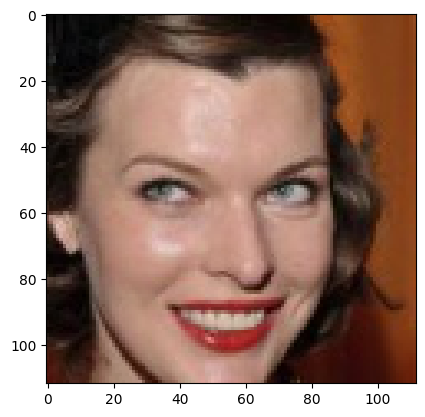

In [36]:
plt.imshow(img)

In [41]:
distance.cosine(emb_layer_model.predict(img)[0], emb_layer_model.predict(img)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


0.0

### Distance for same images, one with a bit of noise

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


0.4404348874657391

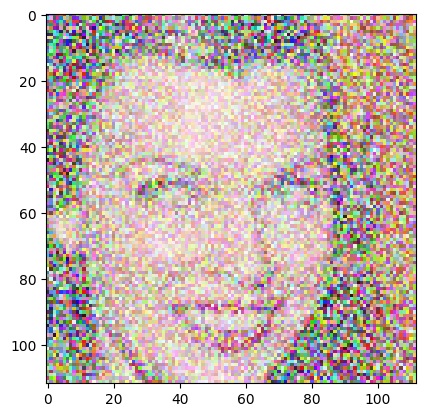

In [63]:
img_2 = np.random.uniform(img)
plt.imshow(img_2[0])
distance.cosine(emb_layer_model.predict(img)[0], emb_layer_model.predict(img_2)[0])

### Distance for different images

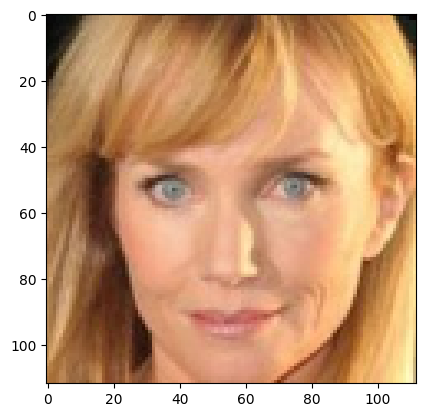

In [56]:
folder_img = os.path.join(path_images, '100/14692.png')
img_2 = imread(folder_img) / 255.
img_2 = np.expand_dims(img_2, axis=0)

plt.imshow(img_2[0])

In [57]:
distance.cosine(emb_layer_model.predict(img)[0], emb_layer_model.predict(img_2)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


0.034317369926140984

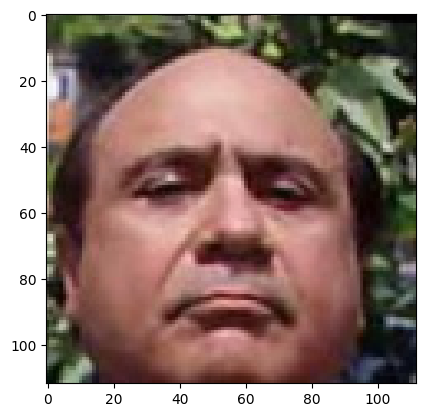

In [58]:
folder_img = os.path.join(path_images, '101/14781.png')
img_2 = imread(folder_img) / 255.
img_2 = np.expand_dims(img_2, axis=0)

plt.imshow(img_2[0])

In [59]:
distance.cosine(emb_layer_model.predict(img)[0], emb_layer_model.predict(img_2)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


0.029483430584112402